In [90]:
import pandas as pd

In [91]:
import warnings
warnings.filterwarnings("ignore")

In [92]:
df = pd.read_csv("./data/customer_churn_data.csv") # ETL da base de dados são colocados num dataframe

In [93]:
df.head() # Exemplo da estrutura do nosso dataset

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [95]:
df.isna().sum().sum() # Fazendo a limpeza dos dados, partindo dos valores NA, aqui encontramos quase 300 deles

np.int64(297)

In [96]:
df["InternetService"] = df["InternetService"].fillna("")

In [97]:
df.isna().sum() # Os valores de NA foram limpos

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [98]:
df.duplicated().sum() # Agora tentamos limpar os dados duplicados, mas a base de dados já não tinha nenhum

np.int64(0)

In [99]:
df.describe() # Um resumo geral dos dados após a limpeza

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [100]:
numeric_columns_data = df.select_dtypes( include = ["number"]) # Separando dados númericos para trabalhar com eles

In [101]:
# Buscamos correlações entre os valores, a quantidade de valores negativos ou muito baixos demonstra baixa correlação no momento (-1 = strong negative, 1 = strong positive)
numeric_columns_data.corr() 

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [102]:
import matplotlib.pyplot as plt

In [103]:
# Vizualizando os dados de churn, notavel que a maioria dos clientes abandona a empresa nesse cenario
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [104]:
# Estudando os dados preliminarmente, analisando a taxa de churn por cobranças mensais, genero, idade, etc.
# Quanto maiores as cobranças mensais, mais chances de churn
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [105]:
# Genero só afeta chances de churn ligeiramente
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [106]:
# Pessoas que usam o serviço por mais tempo tem menos chances de churn
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [107]:
# Idade essencialmente não parecem afetar muito as chances de churn
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

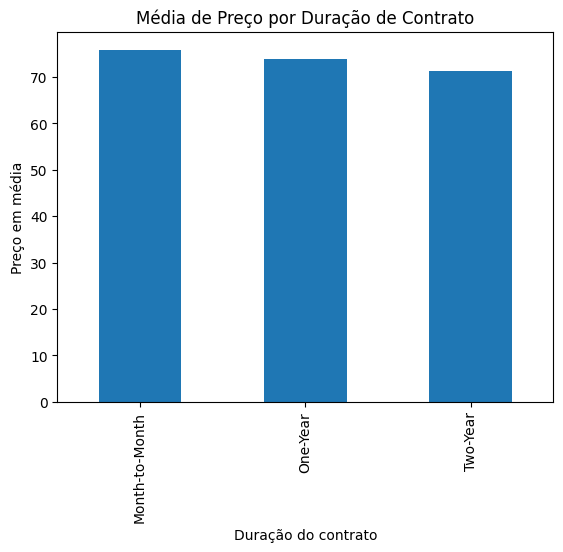

In [108]:
# Notavel que, em geral, quanto menor a duração do contrato, maior o custo para o cliente

df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Média de Preço por Duração de Contrato")
plt.ylabel("Preço em média")
plt.xlabel("Duração do contrato")
plt.show()

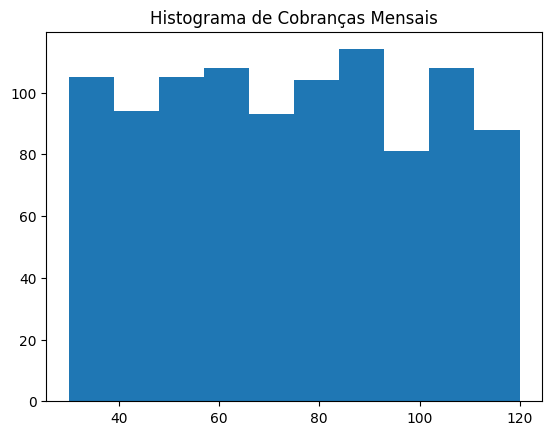

In [109]:
plt.hist(df["MonthlyCharges"])
plt.title("Histograma de Cobranças Mensais")
plt.show()

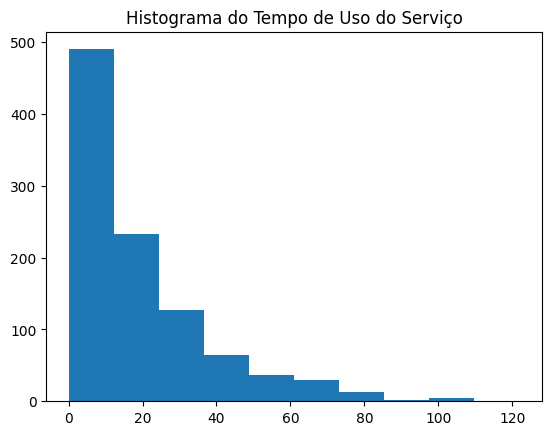

In [110]:
# A vasta maioria dos clientes usa o serviço por pouco tempo

plt.hist(df["Tenure"])
plt.title("Histograma do Tempo de Uso do Serviço")
plt.show()

In [111]:
# Agora partiremos para feature engineering

y = df[["Churn"]]
X = df[["Age", "Gender", "Tenure", "MonthlyCharges"]]

In [112]:
X # Para manter todos os dados como numéricos, vamos definir mulheres como 1 e homens como 0

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [113]:
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)

In [114]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [115]:
# Faremos o mesmo com Churn. Sim passa a ser 1 e Não passa a ser 0
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

In [116]:
y.head(10)

,Churn
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,0
9,1


In [117]:
# Preparando o campo pro treinamento do modelo

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [118]:
from sklearn.preprocessing import StandardScaler

In [119]:
scaler = StandardScaler()

In [120]:
X_train = scaler.fit_transform(X_train)

In [121]:
# Utilizamos um scaler para manter os dados dentro de ranges parecidos

import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [122]:
X_test= scaler.fit_transform(X_test)

In [123]:
# Criamos um metodo para averiguar a precisão do modelo
from sklearn.metrics import accuracy_score
def modelperformance(predictions):
    print("A taxa de precisão do modelo é {}".format(accuracy_score(y_test, predictions)))

In [124]:
from sklearn.model_selection import GridSearchCV

In [125]:
# Agora usaremos Regressão Logística como parte do treinamento da maquina
from sklearn.linear_model import LogisticRegression

In [126]:
log_model = LogisticRegression()

In [127]:
log_model.fit(X_train, y_train)

LogisticRegression()

In [128]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [129]:
# Informando idade, genero, tempo de uso do serviço e cobranças mensais
log_model.predict([[40, 0, 20, 80]])
# O algoritmo preve um churn (relembrando que Churn foi definido como 1)

array([1])

In [130]:
y_pred = log_model.predict(X_test)

In [131]:
# Testando a precisão do modelo
modelperformance(y_pred)

A taxa de precisão do modelo é 0.915


In [132]:
# Agora usaremos a técnica de K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier

In [133]:
# Testaremos diversos parametros para encontrar os mais precisos
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
}

In [134]:
gridkn = GridSearchCV(KNeighborsClassifier(),param_grid, cv=5)

In [135]:
gridkn.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [136]:
# Usamos este metodo para descobrir os parametros com melhor resultado dentre os testados
gridkn.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [137]:
y_pred = gridkn.predict(X_test)

In [ ]:
# KNN se mostra ligeiramente inferior a Regressão Logistica para este problema
modelperformance(y_pred)

A taxa de precisão do modelo é 0.9


In [139]:
# Agora testaremos o algoritmo de Support Vector Machine (SVM)
# Usaremos um tipo especifico de SVM, o Support Vector Classifier (SVC) 
from sklearn.svm import SVC

In [140]:
svm = SVC()

In [141]:
# Testaremos diversos parametros novamente
param_grid = {
    "C" : [0.01,0.1,0.5,1],
    "kernel" : ["linear", "rbf", "poly"]
}

In [142]:
gridsvc = GridSearchCV(svm, param_grid, cv = 5)

In [143]:
gridsvc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [0.01, 0.1, 0.5, 1],
                         'kernel': ['linear', 'rbf', 'poly']})

In [144]:
# Encontramos os melhores parametros dentre os testados
gridsvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [145]:
y_pred = gridsvc.predict(X_test)

In [ ]:
# Identificamos que regressão logistica é ligeiramente mais precisa que SVM para este problema especifico
modelperformance(y_pred)

A taxa de precisão do modelo é 0.91


In [147]:
# Agora testaremos Arvores de Decisão
from sklearn.tree import DecisionTreeClassifier

In [149]:
param_grid = {
    "criterion" : ["gini", "entropy"],
    "splitter" : ["best", "random"],
    "max_depth" : [None, 10, 20, 30],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf" : [1, 2, 4]
}

In [150]:
grid_tree = GridSearchCV(DecisionTreeClassifier(), param_grid, cv = 5)

In [151]:
grid_tree.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20, 30],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [152]:
grid_tree.best_params_

{'criterion': 'gini',
 'max_depth': 20,
 'min_samples_leaf': 4,
 'min_samples_split': 2,
 'splitter': 'random'}

In [153]:
y_pred = grid_tree.predict(X_test)

In [ ]:
# Esse algoritmo resultado até agora
modelperformance(y_pred)

A taxa de precisão do modelo é 0.855


In [155]:
# Tentaremos o mesmo com Random Forest
from sklearn.ensemble import RandomForestClassifier

rfc_model = RandomForestClassifier()

param_grid = {
    "n_estimators" : [32, 64, 128, 256],
    "max_features" : [2, 3, 4],
    "bootstrap" : [True, False]
}

grid_rfc = GridSearchCV(rfc_model, param_grid, cv = 5)

In [156]:
grid_rfc.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'bootstrap': [True, False], 'max_features': [2, 3, 4],
                         'n_estimators': [32, 64, 128, 256]})

In [157]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 4, 'n_estimators': 32}

In [ ]:
# Segue sendo menos satisfatório que SVM e Regressão Logistica
y_pred = grid_rfc.predict(X_test)
modelperformance(y_pred)

A taxa de precisão do modelo é 0.865


É notavel que a taxa de precisão dos modelos pode ser afetada dependendo dos dados de treino, e que diferentes algoritimos podem ser mais ou menos precisos num mesmo problema devido a isso.

In [ ]:
# Usaremos SVM daqui em diante por ter resultados muito similares a Regressão Logistica mas sendo mais maleavel
best_model = gridsvc.best_estimator_

In [160]:
joblib.dump(best_model, "model.pkl")

['model.pkl']